# RAG Without Vectors: How PageIndex Retrieves by Reasoning
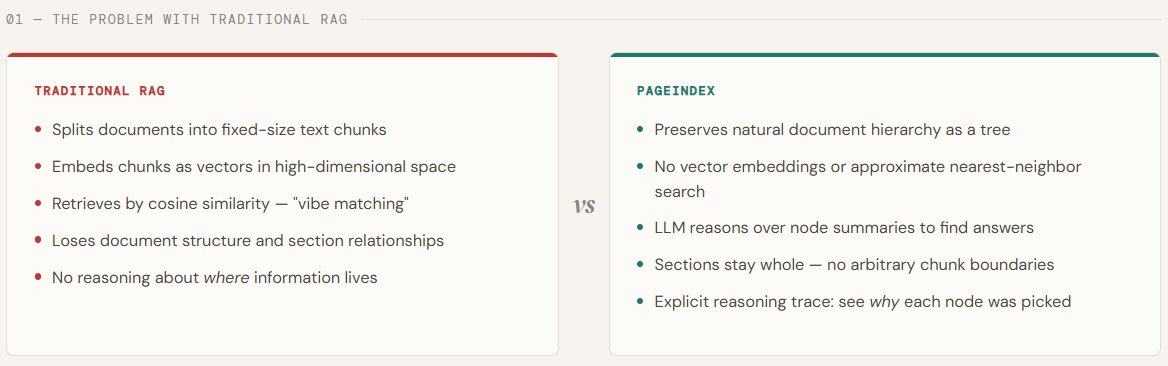

## Setting up the dependencies
For this tutorial, you would require PageIndex & OpenAI API keys. You can get the same from https://dash.pageindex.ai/api-keys and https://platform.openai.com/api-keys respectively.

In [1]:
!pip install pageindex openai requests

In [2]:
from pageindex import PageIndexClient
import pageindex.utils as utils
import os
from getpass import getpass

PAGEINDEX_API_KEY = getpass('Enter PageIndex API Key: ')
pi_client = PageIndexClient(api_key=PAGEINDEX_API_KEY)

Enter PageIndex API Key: ··········


We import the OpenAI client and configure it with an API key to enable access to LLMs. Then, we define an asynchronous helper function that sends prompts to the model and returns the generated response.

In [3]:
import openai

OPENAI_API_KEY = getpass('Enter OpenAI API Key: ')

async def call_llm(prompt, model="gpt-5.4", temperature=0):
    client = openai.AsyncOpenAI(api_key=OPENAI_API_KEY)
    response = await client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        temperature=temperature
    )
    return response.choices[0].message.content.strip()

Enter OpenAI API Key: ··········


## Building the PageIndex Tree
In this chunk, we download the Transformer paper directly from arXiv and submit it to PageIndex, which processes the PDF and builds a hierarchical tree of its sections — each node storing a title, a summary, and the full section text. Once the tree is ready, we print it out to inspect the structure PageIndex has inferred: every chapter, subsection, and nested heading becomes a node in the tree, preserving the document's natural organization exactly as the authors intended it.


In [4]:
# ─────────────────────────────────────────────
# Step 1: Build the PageIndex Tree
# ─────────────────────────────────────────────

# 1.1 Download the Transformer paper and submit it
import os, requests

pdf_url = "https://arxiv.org/pdf/1706.03762.pdf"
pdf_path = os.path.join("data", pdf_url.split("/")[-1])
os.makedirs("data", exist_ok=True)

print("Downloading 'Attention Is All You Need'...")
response = requests.get(pdf_url)
with open(pdf_path, "wb") as f:
    f.write(response.content)
print(f"✅ Saved to {pdf_path}")

doc_id = pi_client.submit_document(pdf_path)["doc_id"]
print(f"📄 Document submitted. doc_id: {doc_id}")

# 1.2 Retrieve the tree (poll until ready)
import time

print("\nWaiting for PageIndex tree to be ready", end="")
while not pi_client.is_retrieval_ready(doc_id):
    print(".", end="", flush=True)
    time.sleep(5)

tree = pi_client.get_tree(doc_id, node_summary=True)["result"]
print("\n\n📂 Document Tree Structure:")
utils.print_tree(tree)

✅ Saved to data/1706.03762.pdf
📄 Document submitted. doc_id: pi-cmnvkub2d0bs101qssqvjlh2f

Waiting for PageIndex tree to be ready....

📂 Document Tree Structure:
[{'title': 'Attention Is All You Need',
  'node_id': '0000',
  'prefix_summary': '# Attention Is All You Need\n\n|  Ashish V...',
  'nodes': [{'title': 'Abstract',
             'node_id': '0001',
             'summary': 'The text introduces the Transformer, a n...'},
            {'title': '2 Background',
             'node_id': '0002',
             'summary': 'This text discusses the background of re...'},
            {'title': '3 Model Architecture',
             'node_id': '0003',
             'prefix_summary': 'The text describes the common encoder-de...',
             'nodes': [{'title': '3.1 Encoder and Decoder Stacks',
                        'node_id': '0004',
                        'summary': 'The text describes the encoder and decod...'},
                       {'title': '3.2 Attention',
                        'node

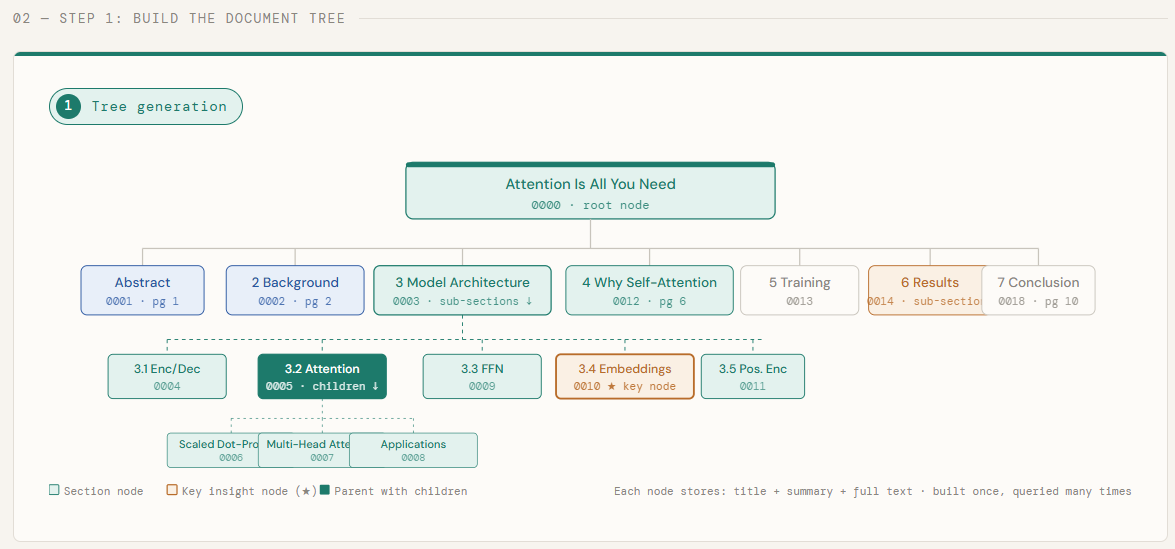

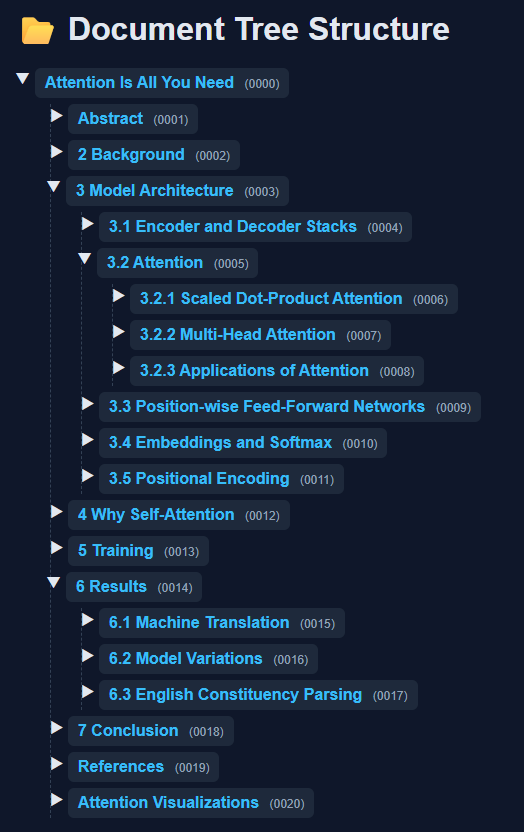

## Reasoning-Based Retrieval
With the tree built, we now run a query that is intentionally cross-cutting — one that can't be answered by a single section of the paper. We strip the full text from each node, leaving only titles and summaries, and pass the entire tree structure to GPT-5.4. The model then reasons over these summaries to identify every node likely to contain a relevant answer, returning both its step-by-step thinking and a list of matched node IDs. This is the core of what makes PageIndex different: the LLM decides where to look before any full text is loaded.
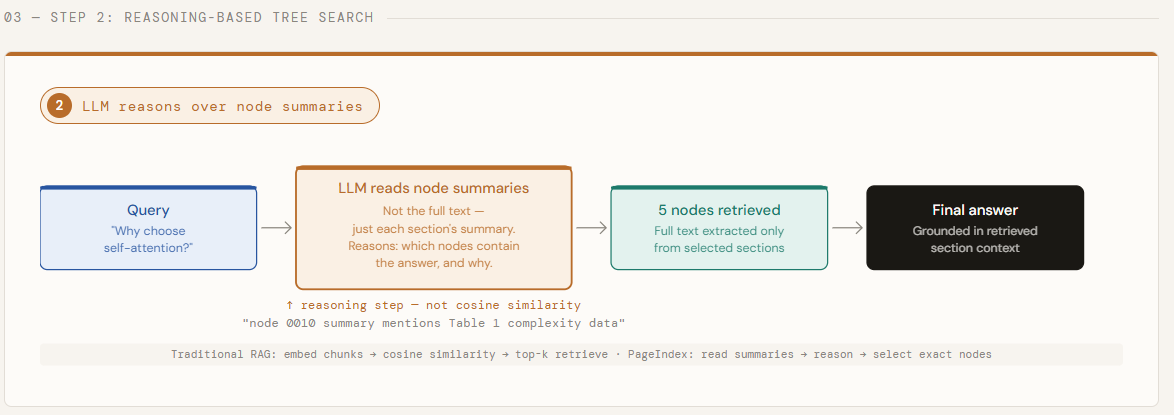

In [6]:
# ─────────────────────────────────────────────
# Step 2: Reasoning-Based Retrieval
# ─────────────────────────────────────────────

# 2.1 Define a query that requires navigating across sections
import json

# This query is intentionally cross-cutting — it can't be answered
# by a single section, which is where tree search shines over top-k.
query = "Why did the authors choose self-attention over recurrence, and what are the complexity trade-offs they compared?"

tree_without_text = utils.remove_fields(tree.copy(), fields=["text"])

search_prompt = f"""
You are given a question and a hierarchical tree structure of a research paper.
Each node has a node_id, title, and a summary of its content.

Your task: identify ALL nodes that are likely to contain information relevant to answering the question.
Think carefully — the answer may be spread across multiple sections.

Question: {query}

Document tree:
{json.dumps(tree_without_text, indent=2)}

Reply ONLY in this JSON format, no preamble:
{{
    "thinking": "<step-by-step reasoning about which nodes are relevant and why>",
    "node_list": ["node_id_1", "node_id_2", ...]
}}
"""

print(f'🔍 Query: "{query}"\n')
print("Running tree search with GPT-5.4...")
tree_search_result = await call_llm(search_prompt)

# 2.2 Inspect the retrieval reasoning and matched nodes
node_map = utils.create_node_mapping(tree)
result_json = json.loads(tree_search_result)

print("\n🧠 LLM Reasoning:")
utils.print_wrapped(result_json["thinking"])

print("\n📌 Retrieved Nodes:")
for node_id in result_json["node_list"]:
    node = node_map[node_id]
    print(f"  • [{node['node_id']}] Page {node['page_index']:>2} — {node['title']}")


🔍 Query: "Why did the authors choose self-attention over recurrence, and what are the complexity trade-offs they compared?"

Running tree search with GPT-5.4...

🧠 LLM Reasoning:
The question asks two things: (1) why the authors chose self-attention over recurrence, and (2) what
complexity trade-offs they compared. The most directly relevant section is '4 Why Self-Attention'
because it explicitly compares self-attention with recurrent and convolutional layers in terms of
computational complexity, parallelizability, and path length/long-range dependencies. The abstract
is also relevant because it states the motivation for removing recurrence: recurrent models have
inherent sequential computation that limits parallelization, while the Transformer improves quality,
parallelizability, and training time. The background section is relevant because it frames the
broader motivation of reducing sequential computation and discusses prior alternatives and long-
range dependency issues. The 'Embed

## Answer Generation
Once the relevant nodes are identified, we pull their full text and stitch it together into a single context block — each section clearly labeled so the model knows where each piece of information comes from. That combined context is then handed to GPT-5.4 with a structured prompt that asks for the core motivation, the specific complexity numbers, and any caveats the authors acknowledged. The model answers using only what was retrieved, grounding every claim directly in the paper's text.
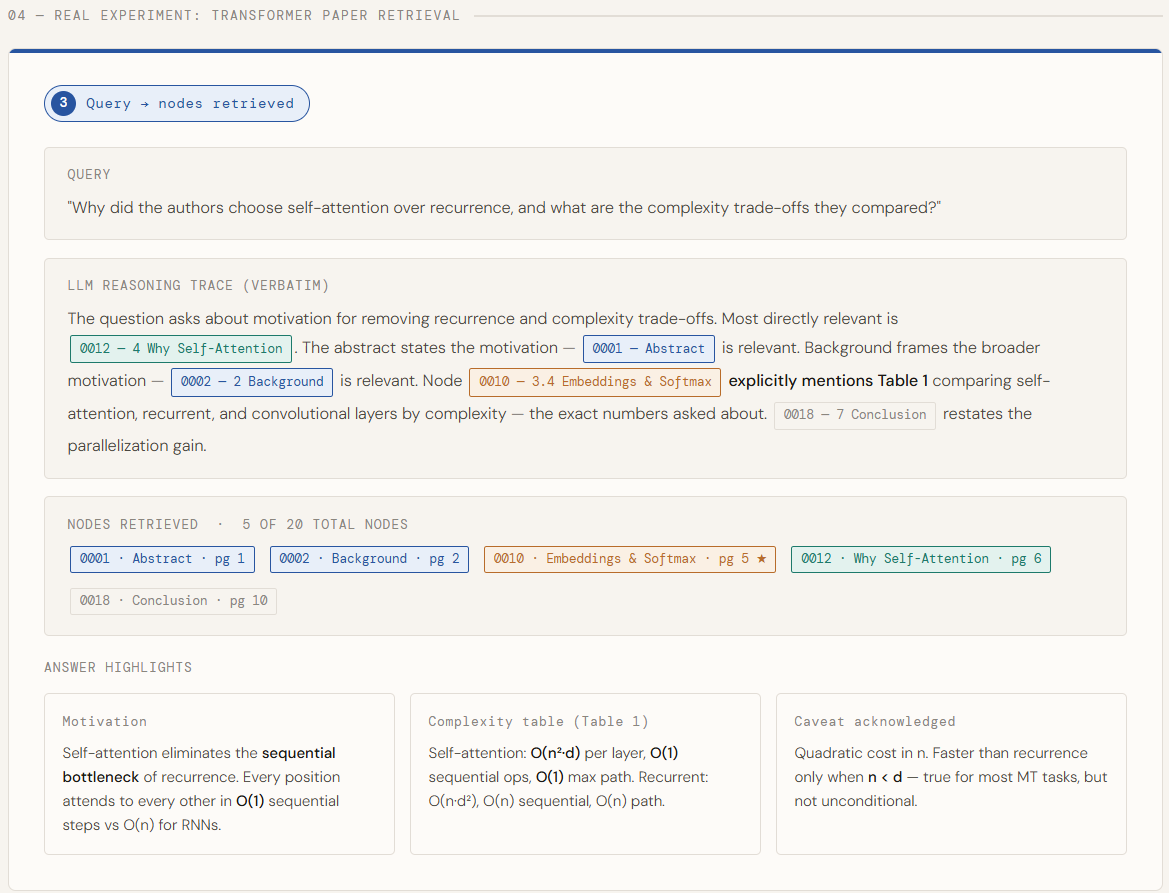

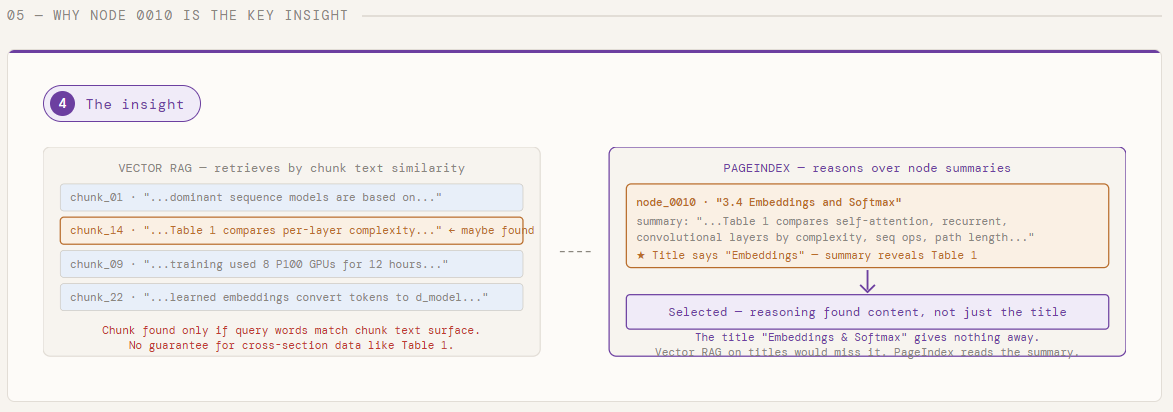

In [7]:
# ─────────────────────────────────────────────
# Step 3: Answer Generation
# ─────────────────────────────────────────────

# 3.1 Stitch together context from all retrieved nodes
node_list = result_json["node_list"]
relevant_content = "\n\n---\n\n".join(
    f"[Section: {node_map[nid]['title']}]\n{node_map[nid]['text']}"
    for nid in node_list
)

print(f"\n📖 Retrieved Context Preview (first 1200 chars):\n")
utils.print_wrapped(relevant_content[:1200] + "...\n")

# 3.2 Generate a structured answer grounded in the retrieved sections
answer_prompt = f"""
You are a technical assistant. Answer the question below using ONLY the provided context.
Be specific — reference actual design choices, numbers, and trade-offs mentioned in the text.

Question: {query}

Context:
{relevant_content}

Structure your answer as:
1. The core motivation for choosing self-attention
2. The specific complexity comparisons made (include any tables or numbers)
3. Any caveats or limitations the authors acknowledged
"""

print("💬 Generating answer...\n")
answer = await call_llm(answer_prompt)

print("─" * 60)
print("✅ Final Answer:\n")
utils.print_wrapped(answer)
print("─" * 60)


📖 Retrieved Context Preview (first 1200 chars):

[Section: Abstract]
## Abstract

The dominant sequence transduction models are based on complex recurrent or convolutional neural
networks that include an encoder and a decoder. The best performing models also connect the encoder
and decoder through an attention mechanism. We propose a new simple network architecture, the
Transformer, based solely on attention mechanisms, dispensing with recurrence and convolutions
entirely. Experiments on two machine translation tasks show these models to be superior in quality
while being more parallelizable and requiring significantly less time to train. Our model achieves
28.4 BLEU on the WMT 2014 English-to-German translation task, improving over the existing best
results, including ensembles, by over 2 BLEU. On the WMT 2014 English-to-French translation task,
our model establishes a new single-model state-of-the-art BLEU score of 41.8 after training for 3.5
days on eight GPUs, a small fraction of 

## Testing with a Second Query
To show that the tree is built once and reused at no extra cost, we run a second query — this time targeting a localized mechanism rather than a cross-cutting design decision. The same tree structure is passed to GPT-5.4, which narrows its search to just the attention subsections, retrieves their full text, and generates a clean explanation of how multi-head attention works and why the scaling factor matters. No re-indexing, no re-embedding — just a new question against the same tree.


In [8]:
query2 = "How does the multi-head attention mechanism work, and what is the role of scaling in dot-product attention?"

search_prompt2 = f"""
You are given a question and a hierarchical tree structure of a research paper.
Identify all nodes likely to contain the answer.

Question: {query2}

Document tree:
{json.dumps(tree_without_text, indent=2)}

Reply ONLY in this JSON format:
{{
    "thinking": "<reasoning>",
    "node_list": ["node_id_1", ...]
}}
"""

print(f'\n\n🔍 Second Query: "{query2}"\n')
result2_raw = await call_llm(search_prompt2)
result2 = json.loads(result2_raw)

print("🧠 Reasoning:")
utils.print_wrapped(result2["thinking"])

relevant_content2 = "\n\n---\n\n".join(
    f"[Section: {node_map[nid]['title']}]\n{node_map[nid]['text']}"
    for nid in result2["node_list"]
)

answer_prompt2 = f"""
Answer the following question using ONLY the provided context.
Explain the mechanism clearly, as if for a technical blog post.

Question: {query2}
Context: {relevant_content2}
"""

answer2 = await call_llm(answer_prompt2)
print("\n✅ Answer:\n")
utils.print_wrapped(answer2)



🔍 Second Query: "How does the multi-head attention mechanism work, and what is the role of scaling in dot-product attention?"

🧠 Reasoning:
The question asks specifically about how multi-head attention works and the role of scaling in dot-
product attention. The most relevant content is in Section 3.2 Attention and especially its
subsections: 3.2.1 explains scaled dot-product attention and why the 1/sqrt(d_k) scaling is used,
while 3.2.2 explains the multi-head attention mechanism. The parent section 3.2 is also likely
useful because it introduces attention generally and frames both subsections.

✅ Answer:

Multi-head attention builds on scaled dot-product attention.

First, attention takes a query and compares it against a set of keys to decide how much weight to
assign to each corresponding value. The output is a weighted sum of the values, where the weights
come from a compatibility score between the query and each key.

In scaled dot-product attention, the queries, keys, and valu

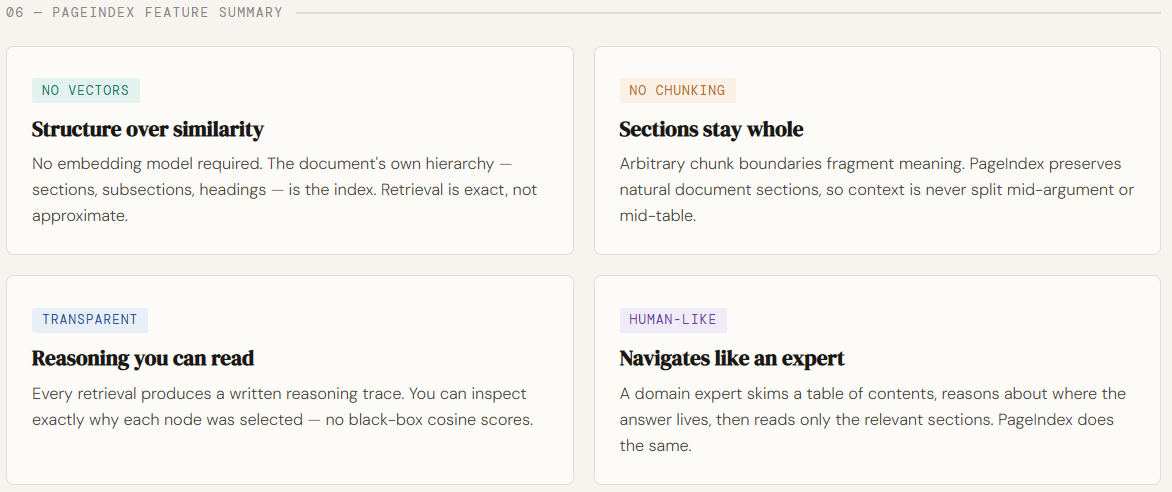